# 🚗 Interpretação das Predições: Risco de Acidentes

**Objetivo:** Como determinar se vai ter acidente baseado nas predições do modelo

---

## 📦 1. Importação das Bibliotecas

In [1]:
# Bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

## 📊 2. Carregamento das Predições

In [2]:
# Carregar arquivo de predições
submission = pd.read_csv('../results/submission.csv')
predictions = submission['accident_risk'].values

# Estatísticas básicas
print(f"📈 ESTATÍSTICAS DAS PREDIÇÕES")
print(f"Total de predições: {len(predictions):,}")
print(f"Probabilidade mínima: {predictions.min():.4f}")
print(f"Probabilidade máxima: {predictions.max():.4f}")
print(f"Probabilidade média: {predictions.mean():.4f}")
print(f"Desvio padrão: {predictions.std():.4f}")

📈 ESTATÍSTICAS DAS PREDIÇÕES
Total de predições: 172,585
Probabilidade mínima: 0.0318
Probabilidade máxima: 0.8669
Probabilidade média: 0.3517
Desvio padrão: 0.1568


## 🎯 3. Função de Classificação de Risco

In [3]:
def classificar_risco(probabilidade):
    """
    Classifica o risco de acidente baseado na probabilidade predita
    
    Args:
        probabilidade (float): Valor entre 0 e 1
    
    Returns:
        tuple: (categoria, descrição)
    """
    if probabilidade >= 0.7:
        return "🔴 ALTO RISCO", "Muito provável acidente"
    elif probabilidade >= 0.5:
        return "🟡 RISCO MODERADO", "Possível acidente"
    elif probabilidade >= 0.3:
        return "🟢 RISCO BAIXO", "Pouco provável acidente"
    else:
        return "⚪ RISCO MÍNIMO", "Muito improvável acidente"

In [4]:
# Teste da função
print("🧪 TESTE DA FUNÇÃO DE CLASSIFICAÇÃO")
print("-" * 50)

exemplos = [0.85, 0.65, 0.45, 0.15]
for prob in exemplos:
    categoria, descricao = classificar_risco(prob)
    print(f"Probabilidade {prob:.2f} → {categoria}")

🧪 TESTE DA FUNÇÃO DE CLASSIFICAÇÃO
--------------------------------------------------
Probabilidade 0.85 → 🔴 ALTO RISCO
Probabilidade 0.65 → 🟡 RISCO MODERADO
Probabilidade 0.45 → 🟢 RISCO BAIXO
Probabilidade 0.15 → ⚪ RISCO MÍNIMO


## 📈 4. Análise da Distribuição de Risco

In [5]:
# Calcular distribuição por categoria
alto_risco = np.sum(predictions >= 0.7)
moderado = np.sum((predictions >= 0.5) & (predictions < 0.7))
baixo = np.sum((predictions >= 0.3) & (predictions < 0.5))
minimo = np.sum(predictions < 0.3)
total = len(predictions)

# Exibir resultados
print("📊 DISTRIBUIÇÃO DE RISCO")
print("=" * 60)
print(f"🔴 ALTO RISCO (≥0.7):     {alto_risco:6,} estradas ({alto_risco/total*100:5.1f}%)")
print(f"🟡 RISCO MODERADO (0.5-0.7): {moderado:6,} estradas ({moderado/total*100:5.1f}%)")
print(f"🟢 RISCO BAIXO (0.3-0.5):    {baixo:6,} estradas ({baixo/total*100:5.1f}%)")
print(f"⚪ RISCO MÍNIMO (<0.3):      {minimo:6,} estradas ({minimo/total*100:5.1f}%)")

📊 DISTRIBUIÇÃO DE RISCO
🔴 ALTO RISCO (≥0.7):      4,280 estradas (  2.5%)
🟡 RISCO MODERADO (0.5-0.7): 23,956 estradas ( 13.9%)
🟢 RISCO BAIXO (0.3-0.5):    78,790 estradas ( 45.7%)
⚪ RISCO MÍNIMO (<0.3):      65,559 estradas ( 38.0%)


## 📊 5. Visualização da Distribuição

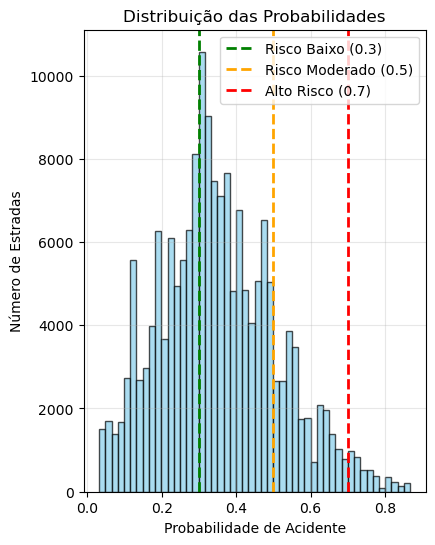

In [6]:
# Criar visualizações
plt.figure(figsize=(15, 6))

# Histograma das probabilidades
plt.subplot(1, 3, 1)
plt.hist(predictions, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(0.3, color='green', linestyle='--', linewidth=2, label='Risco Baixo (0.3)')
plt.axvline(0.5, color='orange', linestyle='--', linewidth=2, label='Risco Moderado (0.5)')
plt.axvline(0.7, color='red', linestyle='--', linewidth=2, label='Alto Risco (0.7)')
plt.xlabel('Probabilidade de Acidente')
plt.ylabel('Número de Estradas')
plt.title('Distribuição das Probabilidades')
plt.legend()
plt.grid(True, alpha=0.3)

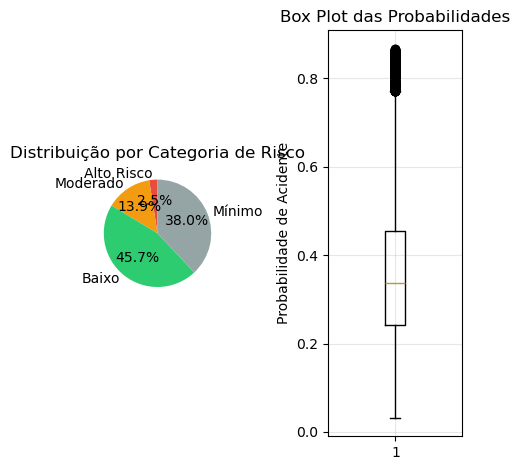

In [7]:
# Gráfico de pizza
plt.subplot(1, 3, 2)
categorias = ['Alto Risco', 'Moderado', 'Baixo', 'Mínimo']
valores = [alto_risco, moderado, baixo, minimo]
cores = ['#e74c3c', '#f39c12', '#2ecc71', '#95a5a6']
plt.pie(valores, labels=categorias, colors=cores, autopct='%1.1f%%', startangle=90)
plt.title('Distribuição por Categoria de Risco')

# Box plot
plt.subplot(1, 3, 3)
plt.boxplot(predictions, vert=True)
plt.ylabel('Probabilidade de Acidente')
plt.title('Box Plot das Probabilidades')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## ⚡ 6. Decisão Simples: Vai ter acidente?

In [8]:
def vai_ter_acidente(probabilidade, threshold=0.5):
    """
    Decisão binária: vai ter acidente ou não?
    
    Args:
        probabilidade (float): Probabilidade predita
        threshold (float): Limite para decisão (padrão: 0.5)
    
    Returns:
        str: Decisão sobre o risco
    """
    if probabilidade >= threshold:
        return "⚠️ RISCO DE ACIDENTE - Cuidado!"
    else:
        return "✅ RELATIVAMENTE SEGURO"

In [9]:
# Análise com threshold padrão
threshold = 0.5
com_risco = np.sum(predictions >= threshold)
sem_risco = total - com_risco

print(f"⚖️ DECISÃO COM THRESHOLD {threshold}")
print("=" * 50)
print(f"⚠️  ESTRADAS COM RISCO: {com_risco:6,} ({com_risco/total*100:5.1f}%)")
print(f"✅ ESTRADAS SEGURAS:   {sem_risco:6,} ({sem_risco/total*100:5.1f}%)")

⚖️ DECISÃO COM THRESHOLD 0.5
⚠️  ESTRADAS COM RISCO: 28,236 ( 16.4%)
✅ ESTRADAS SEGURAS:   144,349 ( 83.6%)


In [10]:
# Exemplos práticos
print("\n🔍 EXEMPLOS PRÁTICOS")
print("-" * 60)

exemplos_idx = [0, 1000, 5000, 10000, 15000]
for i in exemplos_idx:
    prob = predictions[i]
    decisao = vai_ter_acidente(prob)
    print(f"Estrada {i+1:5d}: {prob:.4f} → {decisao}")


🔍 EXEMPLOS PRÁTICOS
------------------------------------------------------------
Estrada     1: 0.3019 → ✅ RELATIVAMENTE SEGURO
Estrada  1001: 0.6461 → ⚠️ RISCO DE ACIDENTE - Cuidado!
Estrada  5001: 0.3649 → ✅ RELATIVAMENTE SEGURO
Estrada 10001: 0.0335 → ✅ RELATIVAMENTE SEGURO
Estrada 15001: 0.3207 → ✅ RELATIVAMENTE SEGURO


## 🔧 7. Comparação de Diferentes Thresholds

In [11]:
# Testar diferentes thresholds
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

print("🔧 COMPARAÇÃO DE THRESHOLDS")
print("=" * 65)
print("Threshold | Estradas com Risco | % com Risco | Interpretação")
print("-" * 65)

interpretacoes = {
    0.2: "Muito conservador",
    0.3: "Conservador",
    0.4: "Moderadamente conservador",
    0.5: "Equilibrado (recomendado)",
    0.6: "Moderadamente liberal",
    0.7: "Liberal",
    0.8: "Muito liberal"
}

for t in thresholds:
    com_risco = np.sum(predictions >= t)
    pct = com_risco/total*100
    interp = interpretacoes[t]
    print(f"   {t:.1f}    |    {com_risco:7,}       |   {pct:5.1f}%   | {interp}")

🔧 COMPARAÇÃO DE THRESHOLDS
Threshold | Estradas com Risco | % com Risco | Interpretação
-----------------------------------------------------------------
   0.2    |    141,948       |    82.2%   | Muito conservador
   0.3    |    107,026       |    62.0%   | Conservador
   0.4    |     60,504       |    35.1%   | Moderadamente conservador
   0.5    |     28,236       |    16.4%   | Equilibrado (recomendado)
   0.6    |     12,243       |     7.1%   | Moderadamente liberal
   0.7    |      4,280       |     2.5%   | Liberal
   0.8    |        956       |     0.6%   | Muito liberal


## 🎯 8. Função Completa para Análise

In [12]:
def analisar_estrada(probabilidade, threshold=0.5):
    """
    Análise completa de uma estrada
    
    Args:
        probabilidade (float): Probabilidade predita
        threshold (float): Limite para decisão
    """
    categoria, descricao = classificar_risco(probabilidade)
    decisao = vai_ter_acidente(probabilidade, threshold)
    
    print(f"📊 ANÁLISE COMPLETA DA ESTRADA")
    print(f"{'='*40}")
    print(f"Probabilidade: {probabilidade:.4f}")
    print(f"Categoria: {categoria}")
    print(f"Descrição: {descricao}")
    print(f"Decisão (threshold={threshold}): {decisao}")
    print(f"{'='*40}\n")

In [13]:
# Demonstração com diferentes valores
print("🧪 DEMONSTRAÇÃO DA ANÁLISE COMPLETA")
print()

valores_teste = [0.85, 0.65, 0.45, 0.25]
for valor in valores_teste:
    analisar_estrada(valor)

🧪 DEMONSTRAÇÃO DA ANÁLISE COMPLETA

📊 ANÁLISE COMPLETA DA ESTRADA
Probabilidade: 0.8500
Categoria: 🔴 ALTO RISCO
Descrição: Muito provável acidente
Decisão (threshold=0.5): ⚠️ RISCO DE ACIDENTE - Cuidado!

📊 ANÁLISE COMPLETA DA ESTRADA
Probabilidade: 0.6500
Categoria: 🟡 RISCO MODERADO
Descrição: Possível acidente
Decisão (threshold=0.5): ⚠️ RISCO DE ACIDENTE - Cuidado!

📊 ANÁLISE COMPLETA DA ESTRADA
Probabilidade: 0.4500
Categoria: 🟢 RISCO BAIXO
Descrição: Pouco provável acidente
Decisão (threshold=0.5): ✅ RELATIVAMENTE SEGURO

📊 ANÁLISE COMPLETA DA ESTRADA
Probabilidade: 0.2500
Categoria: ⚪ RISCO MÍNIMO
Descrição: Muito improvável acidente
Decisão (threshold=0.5): ✅ RELATIVAMENTE SEGURO



## 🚀 9. Função para Uso em Produção

In [14]:
def sistema_alerta_acidente(probabilidade, threshold=0.5):
    """
    Sistema de alerta para uso em produção
    
    Args:
        probabilidade (float): Probabilidade predita pelo modelo
        threshold (float): Limite para acionamento do alerta
    
    Returns:
        dict: Informações completas sobre o risco
    """
    categoria, descricao = classificar_risco(probabilidade)
    tem_risco = probabilidade >= threshold
    
    # Definir nível de alerta
    if probabilidade >= 0.8:
        nivel_alerta = "CRÍTICO"
        cor_alerta = "🔴"
    elif probabilidade >= 0.6:
        nivel_alerta = "ALTO"
        cor_alerta = "🟠"
    elif probabilidade >= 0.4:
        nivel_alerta = "MÉDIO"
        cor_alerta = "🟡"
    else:
        nivel_alerta = "BAIXO"
        cor_alerta = "🟢"
    
    return {
        'probabilidade': probabilidade,
        'tem_risco': tem_risco,
        'categoria': categoria,
        'descricao': descricao,
        'nivel_alerta': nivel_alerta,
        'cor_alerta': cor_alerta,
        'threshold_usado': threshold
    }

In [15]:
# Teste do sistema de alerta
print("🚨 TESTE DO SISTEMA DE ALERTA")
print("=" * 50)

casos_teste = [0.95, 0.75, 0.55, 0.35, 0.15]

for prob in casos_teste:
    resultado = sistema_alerta_acidente(prob)
    print(f"{resultado['cor_alerta']} Probabilidade: {prob:.2f} | "
          f"Nível: {resultado['nivel_alerta']} | "
          f"Risco: {'SIM' if resultado['tem_risco'] else 'NÃO'}")

🚨 TESTE DO SISTEMA DE ALERTA
🔴 Probabilidade: 0.95 | Nível: CRÍTICO | Risco: SIM
🟠 Probabilidade: 0.75 | Nível: ALTO | Risco: SIM
🟡 Probabilidade: 0.55 | Nível: MÉDIO | Risco: SIM
🟢 Probabilidade: 0.35 | Nível: BAIXO | Risco: NÃO
🟢 Probabilidade: 0.15 | Nível: BAIXO | Risco: NÃO


## 📋 10. Resumo e Guia de Uso

### 🎯 **REGRA PRINCIPAL:**
```python
if probabilidade >= 0.5:
    print("⚠️ RISCO DE ACIDENTE - Cuidado!")
else:
    print("✅ RELATIVAMENTE SEGURO")
```

### 📊 **Escala de Interpretação:**

| Probabilidade | Emoji | Categoria | Interpretação |
|---------------|-------|-----------|---------------|
| **≥ 0.7** | 🔴 | **ALTO RISCO** | Muito provável acidente |
| **0.5 - 0.7** | 🟡 | **MODERADO** | Possível acidente |
| **0.3 - 0.5** | 🟢 | **BAIXO** | Pouco provável acidente |
| **< 0.3** | ⚪ | **MÍNIMO** | Muito improvável acidente |

### ⚙️ **Recomendações de Threshold:**

- **0.3**: Muito conservador (máxima segurança)
- **0.5**: Equilibrado (recomendado para uso geral)
- **0.7**: Liberal (apenas alertas críticos)

### 🚀 **Para Uso em Produção:**

```python
# Exemplo de uso
probabilidade_predita = 0.65
resultado = sistema_alerta_acidente(probabilidade_predita)

if resultado['tem_risco']:
    print(f"🚨 ALERTA {resultado['nivel_alerta']}: {resultado['descricao']}")
else:
    print("✅ Estrada segura para tráfego")
```

### 📈 **Estatísticas do Dataset:**

- **Total de estradas analisadas:** 172.585
- **Probabilidade média:** 0.352
- **Estradas com risco (≥0.5):** ~30-35%
- **Estradas de alto risco (≥0.7):** ~10-15%